# Hele-Shaw Cells — Simulation Walkthrough

This notebook walks you through the **hele-shaw-cells-example**
benchmark end-to-end: from cloning the repo, to building the
OpenFOAM Docker image, to running the simulation, to inspecting
the fingers and the metrics.

**Prerequisites**

- Docker (≥ 20.10). Get it from <https://docs.docker.com/get-docker/>.
- On macOS with Colima: run `colima start` before launching Jupyter.
  The notebook shells out to `docker`; if the daemon is down you'll
  get a `FileNotFoundError` (we deliberately do not guard the call).
- Python 3.10 or newer.
- About 2 GB of free disk space (the Docker image is 1.83 GB).
- About 1 GB more for the simulation output (~720 MB for the full run).

**Expected runtime on a native amd64 host**: 10-15 minutes (dominated
by the simulation itself; each configuration takes 3-5 minutes).

**On an arm64 host (e.g. Apple Silicon)**: ~30-60 minutes. The
`opencfd/openfoam-default:2112` base image is amd64-only; Docker uses
QEMU emulation, which adds roughly 4× overhead but produces identical
results.

**Where to get help**

- Mathematical model: see `docs/hele-shaw-cells.md` in this repo.
- Troubleshooting: see `docs/troubleshooting.md`.
- ROHub upload + SPARQL queries: see `notebooks/RoCrate.ipynb`.
- The original Docker-runnable build (bit-exact baseline):
  [`hele-shaw-cells-runnable`](https://github.com/Simulation-Benchmarks/hele-shaw-cells-example/blob/main/docs/hele-shaw-cells.md#relationship-to-hele-shaw-cells-runnable).


In [3]:
import os, subprocess, time, json, sys
from pathlib import Path

# ---- Configuration: set these before running the heavy cells ----
#
# RUN_SIMULATION: 1 = run the simulation; 0 = skip the heavy cells
#                 (useful on slow machines — the math + workflow +
#                  visualization skeleton still work).
# CONFIGURATIONS: space-separated list of configuration IDs to run.
#                 '1' = reference (fastest); '1 2 3' = full sweep.
os.environ.setdefault("RUN_SIMULATION", "1")
os.environ.setdefault("CONFIGURATIONS", "1 2 3")

REPO_URL = "https://github.com/Simulation-Benchmarks/hele-shaw-cells-example.git"
BRANCH = "main"
REPO_DIR = "hele-shaw-cells-example"

# Heuristics: are we already inside the repo root? If so, stay.
# Markers are the unique top-level paths that distinguish the repo
# from a generic directory.
REPO_ROOT_MARKERS = [
    "parameters_1.json",
    "openfoam/case_template/",
    ".github/workflows/run-benchmark.yml",
]

def looks_like_repo_root(p):
    return all((p / m).exists() for m in REPO_ROOT_MARKERS)

# A directory with the markers could still be a stale nested clone
# from a previous run. Verify by checking that the git origin
# matches the expected URL.
def origin_matches(candidate, expected_url):
    r = subprocess.run(
        ["git", "-C", str(candidate), "config", "--get", "remote.origin.url"],
        capture_output=True, text=True, check=False,
    )
    if r.returncode != 0:
        return False
    actual = r.stdout.strip()
    # Accept both https and ssh forms of the same repo.
    ssh = expected_url.replace("https://github.com/", "git@github.com:").rstrip(".git") + ".git"
    return actual in (expected_url, expected_url.rstrip(".git"), ssh)

# Resolve the actual repo root. Walk up from the kernel's cwd if
# necessary, so the cell works whether Jupyter was launched from
# the repo root OR from a subdirectory (e.g. `notebooks/` when
# nbconvert is invoked relative to the input path).
def find_repo_root(start):
    p = start.resolve()
    # First, find all candidate roots by walking up. Then, if there
    # are multiple candidates (e.g. a stale nested clone inside a
    # fresh checkout), prefer the OUTERMOST one. The outermost is
    # the real repo; the inner is a stale artifact.
    candidates = []
    for candidate in [p, *p.parents]:
        if looks_like_repo_root(candidate) and origin_matches(candidate, REPO_URL):
            candidates.append(candidate)
    if not candidates:
        return None
    # Outermost = the one with the longest path (i.e. closest to /)
    # OR the one whose parent is also a candidate (the outermost).
    # Simplest: sort by string length descending, take the longest.
    return max(candidates, key=lambda c: len(str(c)))

cwd = Path.cwd()
root = find_repo_root(cwd)
if root is not None:
    if root != cwd:
        os.chdir(root)
        print(f"Found the repo at {root}; entered it.")
    else:
        print(f"Already inside the repo at {root}; using it directly.")
else:
    # No existing clone with a matching origin. Clone into the
    # kernel's cwd (NOT into a notebooks/ subdirectory) and enter it.
    print(f"Cloning {REPO_URL} (branch {BRANCH}) into {cwd / REPO_DIR} ...")
    subprocess.run(["git", "clone", "--depth", "1", "-b", BRANCH, REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

# Show the user where we are and the latest commits.
print(f"\nNow in: {Path.cwd()}")
print("Latest 5 commits:")
subprocess.run(["git", "log", "--oneline", "-n", "5"])


Already inside the repo at /Users/vasiliy/Documents/GitHub/V-V-Betty/hele-shaw-cells-example; using it directly.

Now in: /Users/vasiliy/Documents/GitHub/V-V-Betty/hele-shaw-cells-example
Latest 5 commits:
8ec0825 Phase 36: add Cartesian (X-Y) fingers plot alongside the polar one
86df6e1 Phase 35: fix 4-quadrant cell layout in plot_fingers.py
3ce4456 Phase 34: fix inlet alpha.air value (0→1) + embed fingers figure in notebook
5eeec3c Phase 33: fix plot_fingers parameters-path search order
df08547 Phase 32: README + docs/getting_started.md


CompletedProcess(args=['git', 'log', '--oneline', '-n', '5'], returncode=0)

## Build the OpenFOAM Docker image

The image is built on top of `opencfd/openfoam-default:2112` —
the official OpenCFD image with OpenFOAM-v2112 pre-built. We add
a 30-second `wmake` of our custom `heleShawFoam` solver on top.

Image size on disk: **1.83 GB** (vs ~6.6 GB for a from-source OF
build). Compressed: ~400 MB.

The `Dockerfile` is at `openfoam/Dockerfile`. It is a single-stage
build; the build context is the `openfoam/` directory.


In [6]:
import time
# Read RUN_SIMULATION directly from the env (this cell runs before the
# cell that defines RUN_SIM).
RUN_SIM = os.environ.get("RUN_SIMULATION", "1") == "1"
if not RUN_SIM:
    print("RUN_SIMULATION=0; skipping the Docker build.")
    print("If you want to run the simulation, set RUN_SIMULATION=1")
    print("in the cell at the top of this notebook and re-run from here.")
    print()
    print("Verifying that the image exists (cached from a prior run):")
    r = subprocess.run(["docker", "images", "hele-shaw"], capture_output=True, text=True)
    print(r.stdout or r.stderr)
else:
    t0 = time.monotonic()
    print("Building the hele-shaw image (this will take a few minutes on a fresh pull)...")
    # Three invocation styles, in order of preference:
    #  1. `docker buildx build --load` — modern Docker with the
    #     buildx component (>= Docker 23.0+ with buildx installed).
    #  2. `docker build` — legacy path; emits a deprecation warning on
    #     modern Docker, but works on any version.
    # We try (1) first, then (2) if (1) fails with 'unknown flag'
    # (which means the user's Docker lacks the buildx component).
    build_cmd = None
    last_err = None
    for candidate in ([
        ["docker", "buildx", "build", "--load", "-t", "hele-shaw:latest", "openfoam/"],
        ["docker", "build", "-t", "hele-shaw:latest", "openfoam/"],
    ]):
        r = subprocess.run(candidate, capture_output=True, text=True)
        last_err = r
        if r.returncode == 0:
            build_cmd = candidate
            print(r.stdout)
            break
        if "unknown flag" in r.stderr or "unknown command" in r.stderr:
            print(f"  (skipping: {' '.join(candidate[1:3])} not supported)")
            continue
        # Some other failure (e.g. daemon down) — surface and stop.
        print(r.stdout)
        print(r.stderr, file=__import__('sys').stderr)
        print()
        print(f"docker build failed (rc={r.returncode}). Common causes:")
        print("  - Colima not started: 'colima start'")
        print("  - Docker daemon down: 'docker ps' to verify")
        print("  - Pull throttled: re-run the cell after a few minutes")
        raise subprocess.CalledProcessError(r.returncode, candidate, r.stderr)
    if build_cmd is None:
        # Both buildx and legacy build were rejected as 'unknown'.
        if last_err is not None:
            print(last_err.stdout)
            print(last_err.stderr, file=__import__('sys').stderr)
        raise RuntimeError(
            "Could not find a working 'docker build' invocation. "
            "Install the buildx component or upgrade to Docker 23+."
        )
    elapsed = time.monotonic() - t0
    print(f"\nBuild completed in {elapsed:.0f} s via: {' '.join(build_cmd[1:3])}")
    subprocess.run(["docker", "images", "hele-shaw"])


Building the hele-shaw image (this will take a few minutes on a fresh pull)...
  (skipping: buildx build not supported)
Sending build context to Docker daemon  20.55MB

Step 1/12 : FROM opencfd/openfoam-default:2112
 ---> 7da1ae59a868
Step 2/12 : USER root
 ---> [Warning] The requested image's platform (linux/amd64) does not match the detected host platform (linux/arm64/v8) and no specific platform was requested
 ---> Running in 1e9449976d01
 ---> Removed intermediate container 1e9449976d01
 ---> 1617d64ba5fd
Step 3/12 : SHELL ["/bin/bash", "-lc"]
 ---> [Warning] The requested image's platform (linux/amd64) does not match the detected host platform (linux/arm64/v8) and no specific platform was requested
 ---> Running in cabb00155fc3
 ---> Removed intermediate container cabb00155fc3
 ---> 77a19ba4b025
Step 4/12 : ENV SHELL=/bin/bash     WM_PROJECT_VERSION=v2112     FOAM_API=2112
 ---> [Warning] The requested image's platform (linux/amd64) does not match the detected host platform (linux

## Mathematical model

The full math is in [`docs/hele-shaw-cells.md`](docs/hele-shaw-cells.md).
The summary below covers what you need to *interpret* the simulation
results. MathJax rendering is on by default in Jupyter, so the
LaTeX below renders as equations.


### Governing equations in the gap

We model incompressible two-phase flow in a thin gap $b \ll R$ between
two parallel circular plates. The governing equations are:

$$\nabla \cdot \mathbf{u} = 0$$

$$\rho \left(\frac{\partial \mathbf{u}}{\partial t} + \mathbf{u} \cdot \nabla \mathbf{u}\right) = -\nabla p + \nabla \cdot (2\mu \mathbf{D}) + \mathbf{f}_{\sigma}$$

with $\mathbf{D} = \frac{1}{2}(\nabla \mathbf{u} + \nabla \mathbf{u}^\top)$.
The volume fraction $\alpha \in [0, 1]$ (1 = pure air, 0 = pure soap)
is advected by:

$$\frac{\partial \alpha}{\partial t} + \nabla \cdot (\alpha \mathbf{u}) = 0$$

with the `isoAdvector` scheme adding a sharp-interface compression
term. Surface tension is captured via the Continuum Surface Force
(CSF) model:

$$\mathbf{f}_{\sigma} = \sigma \kappa \nabla \alpha, \qquad \kappa = \nabla \cdot \left(\frac{\nabla \alpha}{|\nabla \alpha|}\right)$$


### Gap-averaged 2D model

For Newtonian flow with no-slip on both plates, averaging across the
gap gives a Darcy-like 2D form:

$$\langle \mathbf{u} \rangle = -\frac{b^2}{12\mu} \nabla p$$

with $\nabla \cdot \langle \mathbf{u} \rangle = Q / (\pi R_\text{in}^2)$
at the inlet. The `heleShawFoam` solver implements the **un-averaged**
(full 3D-in-z) form with a single cell in the z-direction (`NPB = 1`)
and a `gapWidth` parameter, so the result is equivalent to the averaged
model up to discretization error.


### Initial and boundary conditions

**Geometry**:

- $R_\text{in} = 1.5$ mm, $R_\text{out} = 95$ mm, $b = 1$ mm.
- 2D axisymmetric, single cell in z-direction (a gap of height $b$).

**Initial condition**:

- `alpha.air` is uniform 0 (no air anywhere).
- `setFields` (in `system/setFieldsDict`) sets `alpha.air = 1` inside a
  small cylinder (radius 2.5 mm, height 2.4 mm) at the centre, which
  is the initial air bubble.

**Boundary conditions**:

- `inlet` (at $R = R_\text{in}$): `flowRateInletVelocity` with
  prescribed volumetric flow rate $Q$ (the parameter we sweep).
- `outlet` (at $R = R_\text{out}$): `inletOutlet`, allowing outflow.
- `plates` (at $z = \pm b/2$): `fixedValue` (no-slip).

**Fluid properties** (from `constant/transportProperties`):

| Phase | ρ (kg/m³) | k (m²/s) | n (-) |
|---|---|---|---|
| air  | 1.2     | 1.5×10⁻⁵ | 1.0 |
| soap | 1026.6  | 2.0×10⁻³ | 1.0 |

Surface tension coefficient: $\sigma = 0.031$ N/m.

Both phases use the `powerLaw` transport model with $n=1$ (Newtonian).


### Dimensionless numbers

Four dimensionless numbers govern the pattern:

- **Capillary number** $\mathrm{Ca} = \mu_\text{soap} U / \sigma$ —
  ratio of viscous forces to surface tension. Small $\mathrm{Ca}$ means
  surface tension dominates and the fingers are highly branched.
- **Viscosity ratio** $M = \mu_\text{air} / \mu_\text{soap}$ —
  ratio of the displaced fluid's viscosity to the displacing fluid's.
  For the air-soap system, $M \ll 1$ (unfavourable viscosity ratio,
  which is why fingering happens at all).
- **Reynolds number** $\mathrm{Re} = \rho U b / \mu$ —
  ratio of inertial to viscous forces. In this gap, $\mathrm{Re} \ll 1$:
  viscous (Stokes) flow, no inertia.
- **Péclet-like** $\mathrm{Pe} = Q / (D_\alpha R_\text{in})$ —
  ratio of advection to interface diffusion. Here advection wins by
  many orders of magnitude.


In [8]:
# Compute the dimensionless numbers for the reference config.
Q = 4.0e-7          # m^3/s, reference inlet volumetric flow rate
R_in = 1.5e-3       # m, inlet radius
b = 1.0e-3          # m, gap height
rho_soap = 1026.6   # kg/m^3, soap density
mu_soap = 2.0e-3    # Pa.s, soap dynamic viscosity (with n=1, k=mu)
mu_air = 1.5e-5     # Pa.s, air dynamic viscosity (with n=1, k=mu)
sigma = 0.031       # N/m, surface tension coefficient

import math
# The inlet is an annular slot at R=R_in with height b. The gap-
# averaged velocity at the inlet is Q / (2 pi R_in b).
U_inlet = Q / (2 * math.pi * R_in * b)
Ca = mu_soap * U_inlet / sigma
M = mu_air / mu_soap
Re_soap = rho_soap * U_inlet * b / mu_soap
Re_air = 1.2 * U_inlet * b / mu_air

print(f"Inlet gap-averaged velocity:  U = {U_inlet:.4f} m/s")
print(f"Capillary number (soap):     Ca = {Ca:.4f}")
print(f"Viscosity ratio (air/soap):  M  = {M:.5f}")
print(f"Reynolds number (soap):      Re = {Re_soap:.4f}")
print(f"Reynolds number (air):       Re = {Re_air:.4f}")
print()
print("Interpretation:")
print(f"  - Ca << 1: surface tension dominates -> fingers are highly branched.")
print(f"  - M << 1: viscosity ratio is very unfavourable (Saffman-Taylor unstable).")
print(f"  - Re << 1: viscous (Stokes) flow, no inertia.")


Inlet gap-averaged velocity:  U = 0.0424 m/s
Capillary number (soap):     Ca = 0.0027
Viscosity ratio (air/soap):  M  = 0.00750
Reynolds number (soap):      Re = 21.7851
Reynolds number (air):       Re = 3.3953

Interpretation:
  - Ca << 1: surface tension dominates -> fingers are highly branched.
  - M << 1: viscosity ratio is very unfavourable (Saffman-Taylor unstable).
  - Re << 1: viscous (Stokes) flow, no inertia.


### Reference result

A reference result, extracted from the runnable repo's verified run at
$t \approx 10$ s, is shown below. The air bubble has grown from its
initial 2.5-mm radius and developed radial fingers as it displaced the
more viscous soap. The pattern is mesh-dependent at this resolution;
the bulk statistics (number of fingers, mean tip radius) are
qualitatively similar across runs.

![Hele-Shaw viscous fingering at t~=10s](docs/hele-shaw-cells.png)

The full image with all 301 time-step frames is available in the
runnable repo's `testcase/Results/sim_*.avi` (ParaView-readable).


### Solver numerics

The custom solver `heleShawFoam` is based on `interFoam` (the canonical
VOF solver in OpenFOAM) with the `gapWidth` parameter replacing the
third spatial dimension. The interface-capture scheme is `isoAdvector`
(Roenby, Eijkhout, 2016), which gives sharper interfaces than the
default `MULES` limiter.

Solver settings (from `system/controlDict`):

- `endTime = 15` s
- `deltaT = 0.1` s (initial; adaptive via `adjustTimeStep`)
- `writeInterval = 0.05` s → 301 output frames
- `maxCo = 0.5`, `maxAlphaCo = 0.5` (CFL constraints)

The full discretization strategy is in `docs/hele-shaw-cells.md`
§Discretization strategy.


In [9]:
# Sanity check: load the reference parameters and print them structured.
params_1 = json.loads(Path("parameters_1.json").read_text())
print("Reference configuration (parameters_1.json):")
print(json.dumps(params_1, indent=2))


Reference configuration (parameters_1.json):
{
  "configuration": "1",
  "domain": {
    "R_in": 0.0015,
    "R_out": 0.095,
    "b": 0.001
  },
  "mesh": {
    "NPA": 60,
    "NPZ": 60,
    "NPB": 1
  },
  "initial_condition": {
    "bubble_radius": 0.0025,
    "bubble_z_min": -0.0012,
    "bubble_z_max": 0.0012
  },
  "fluids": {
    "air": {
      "rho": 1.2,
      "k": 1.5e-05,
      "n": 1.0
    },
    "soap": {
      "rho": 1026.6,
      "k": 0.002,
      "n": 1.0
    },
    "sigma": 0.031,
    "gapWidth": 0.001
  },
  "boundary_conditions": {
    "inlet_volumetric_flow_rate": 4e-07
  },
  "solver": {
    "endTime": 15.0,
    "deltaT": 0.1,
    "writeInterval": 0.05,
    "maxCo": 0.5,
    "maxAlphaCo": 0.5
  }
}


## The parameter sweep

This benchmark ships with three configurations that probe different
aspects of the simulation:

- **Configuration 1** — the reference. $NPA = NPZ = 60$ (14400 cells),
  $Q = 4 \times 10^{-7}$ m³/s. Wall time: ~3-5 min on native amd64.
- **Configuration 2** — mild mesh refinement. Same $Q$, but $NPA = NPZ = 80$
  (6400 cells). Lets you see how the metric changes with mesh
  discretisation.
- **Configuration 3** — flow-rate variation. Same mesh as config 1, but
  $Q = 8 \times 10^{-7}$ m³/s (twice the default). Lets you see how the
  metric changes with the inlet flow rate.

By default, the notebook runs all three. To run only config 1 (the
fastest end-to-end check), set `CONFIGURATIONS = "1"` in the cell
at the top of this notebook (or in your environment).


In [10]:
# Show the parameter sweep as a pandas DataFrame.
import pandas as pd

rows = []
for p in sorted(Path(".").glob("parameters_*.json")):
    cfg = p.stem.split("_", 1)[1]
    data = json.loads(p.read_text())
    rows.append({
        "configuration": cfg,
        "NPA": data["mesh"]["NPA"],
        "NPZ": data["mesh"]["NPZ"],
        "NPB": data["mesh"]["NPB"],
        "inlet_flow_rate_m3_s": data["boundary_conditions"]["inlet_volumetric_flow_rate"],
        "endTime_s": data["solver"]["endTime"],
        "bubble_radius_m": data["initial_condition"]["bubble_radius"],
    })
sweep = pd.DataFrame(rows).set_index("configuration") if rows else pd.DataFrame()
sweep


,NPA,NPZ,NPB,inlet_flow_rate_m3_s,endTime_s,bubble_radius_m
configuration,,,,,,
1,60,60,1,4.000000e-07,15.0,0.0025
2,80,80,1,4.000000e-07,15.0,0.0025
3,60,60,1,8.000000e-07,15.0,0.0025


**What each config probes**

- Compare configurations 1 and 2: they share the same flow rate but
  differ in mesh resolution. Any difference in `phase1_volume_fraction`
  is mesh-discretisation error.
- Compare configurations 1 and 3: they share the same mesh but differ
  in flow rate. The doubling of $Q$ should give a visibly higher
  air volume fraction at endTime (more air injected = more air in the
  cell).
- Comparing all three at once is a small 2×2 design with the mesh as
  one factor and the flow rate as the other.


## Run the simulation

The simulation is orchestrated by `openfoam/run_benchmark.py`, which
for each configuration:

1. Renders the case templates (Jinja2) using the parameter JSON.
2. Generates the mesh via `create_mesh.py` (a wrapper around
   `circulardomain.py` + `docker run hele-shaw blockMesh`).
3. Runs the simulation via `docker run hele-shaw:latest` (or
   `Allrun` natively with `--native`).
4. Post-processes the log and alpha field to compute the five
   metrics and write `solution_metrics.json`.
5. Packages the run's time-step directories and the rendered OF
   dictionaries into `solution_field_data.zip` (with a
   hand-rolled RO-Crate metadata file).

On native amd64, expect ~3-5 minutes per configuration. On
QEMU-emulated arm64, ~15-20 minutes per configuration.


In [12]:
# Pick which configurations to run. Override at the top of the notebook
# by editing os.environ["CONFIGURATIONS"], or set the env var before
# launching Jupyter: CONFIGURATIONS="1" jupyter lab ...
CONFIGS = os.environ["CONFIGURATIONS"].split()
print(f"Will run {len(CONFIGS)} configuration(s): {CONFIGS}")

# If you want to skip the simulation entirely (e.g. on a slow machine),
# set RUN_SIMULATION=0 in the environment. The math + workflow + viz
# skeleton still works.
RUN_SIM = os.environ.get("RUN_SIMULATION", "1") == "1"
print(f"RUN_SIMULATION = {RUN_SIM}")


Will run 3 configuration(s): ['1', '2', '3']
RUN_SIMULATION = True


In [ ]:
# Generate the workflow config and ensure each config has a mesh tarball.
if RUN_SIM:
    try:
        subprocess.run(["python", "generate_config.py"], check=True)
        print()
        for cfg in CONFIGS:
            if not Path(f"mesh_{cfg}.tar.gz").exists():
                print(f"Creating mesh for configuration {cfg}...")
                t0 = time.monotonic()
                # create_mesh.py calls 'docker run hele-shaw blockMesh'
                # internally. If the Docker daemon is down, it will fail
                # with FileNotFoundError or CalledProcessError; we
                # surface the message and stop the loop.
                subprocess.run(["python", "create_mesh.py", cfg], check=True)
                print(f"  mesh_{cfg}.tar.gz created in {time.monotonic() - t0:.1f} s")
            else:
                print(f"Reusing existing mesh_{cfg}.tar.gz")
    except (subprocess.CalledProcessError, FileNotFoundError) as e:
        print(f"Mesh generation failed: {e}")
        print("Common causes:")
        print("  - Colima not started: 'colima start'")
        print("  - Docker daemon down: 'docker ps' to verify")
        print("  - Missing image: re-run the build cell above")
        raise
else:
    print("RUN_SIMULATION=0; skipping config generation and mesh creation.")


In [ ]:
# The heavy lift: run the simulation for each configuration.
if RUN_SIM:
    overall_t0 = time.monotonic()
    for cfg in CONFIGS:
        print(f"\n{'='*70}")
        print(f"=== Running configuration {cfg} ===")
        print(f"{'='*70}")
        cfg_t0 = time.monotonic()
        try:
            subprocess.run([
                "python", "openfoam/run_benchmark.py",
                "--no-snakemake",
                "--configurations", cfg,
                "--docker-image", "hele-shaw:latest",
            ], check=True)
        except (subprocess.CalledProcessError, FileNotFoundError) as e:
            print(f"\nConfiguration {cfg} FAILED: {e}")
            print("Check:")
            print("  - The Docker image is built (re-run the build cell)")
            print("  - The Colima/Docker daemon is running")
            print(f"  - The mesh_{cfg}.tar.gz exists (re-run the previous cell)")
            raise
        print(f"\nConfiguration {cfg} done in {time.monotonic() - cfg_t0:.0f} s")
    print(f"\nTotal wall time: {time.monotonic() - overall_t0:.0f} s")
else:
    print("RUN_SIMULATION=0; skipping the simulation.")


**What just happened** (during `run_benchmark.py`):

- The OF dictionaries (`0/U`, `0/alpha.air`, `0/p_rgh`,
  `constant/transportProperties`, `system/controlDict`,
  `system/setFieldsDict`) were rendered from the parameter JSON.
- The mesh tarball was untarred into `constant/polyMesh/`.
- `docker run --rm -v $PWD/results/<cfg>:/case hele-shaw:latest` was
  executed, which sourced the OF environment and ran `./Allrun`.
- The post-processing parsed the OF log for the cumulative continuity
  error, the solver-reported phase-1 volume fraction, and the wall
  time. The alpha field at t=15 was parsed for the interface
  length proxy (cells with $0 < \alpha < 1$).
- `solution_metrics.json` and `solution_field_data.zip` (with the
  m4i:-augmented `ro-crate-metadata.json`) were written.


In [ ]:
# Optional: aggregate the per-config metrics into a summary table.
if RUN_SIM and len(CONFIGS) > 1:
    metric_files = [str(Path("results") / cfg / "solution_metrics.json") for cfg in CONFIGS]
    try:
        subprocess.run([
            "python", "openfoam/summarize_results.py",
            *metric_files,
            "--output", "results/summary.json",
        ], check=True)
    except (subprocess.CalledProcessError, FileNotFoundError) as e:
        print(f"summarize_results.py failed: {e}")
        print("Continuing without the aggregated table.")
    if os.environ.get("PLOT", "1") == "1":
        try:
            subprocess.run([
                "python", "openfoam/summarize_metrics.py",
                "--summary-csv", "results/summary.csv",
                "--output-dir", "results",
            ], check=True)
        except (subprocess.CalledProcessError, FileNotFoundError) as e:
            print(f"Plot generation failed (matplotlib missing?): {e}")
elif RUN_SIM:
    print("Only one configuration; skipping aggregation step.")
else:
    print("RUN_SIMULATION=0; skipping aggregation step.")


## Inspect the results

The simulation produces:

- `results/<config>/solution_metrics.json` — the five metrics per
  configuration (phase1_volume_fraction, cumulative_continuity_error,
  interface_length_proxy, wall_time_seconds, time_step_count).
- `results/<config>/solution_field_data.zip` — the time-step dirs, the
  log, the rendered OF dicts, and the m4i:-augmented RO-Crate metadata.
- `results/<config>/fingers.png` — the post-run alpha-field plot
  (generated by `openfoam/plot_fingers.py` below).
- `results/summary.json` / `results/summary.csv` — the aggregated table
  (only if you ran more than one configuration).
- `results/phase1_volume_fraction_vs_*.pdf` — the sweep plots
  (also only if you ran more than one configuration).


In [13]:
# Read the metrics for each configuration and tabulate them.
import pandas as pd

rows = []
for cfg in CONFIGS:
    metrics_path = Path("results") / cfg / "solution_metrics.json"
    if not metrics_path.exists():
        print(f"Skipping {cfg}: {metrics_path} not found")
        continue
    m = json.loads(metrics_path.read_text())["metrics"]
    rows.append({
        "configuration": cfg,
        "phase1_volume_fraction": m.get("phase1_volume_fraction"),
        "cumulative_continuity_error": m.get("cumulative_continuity_error"),
        "interface_length_proxy": m.get("interface_length_proxy"),
        "wall_time_seconds": m.get("wall_time_seconds"),
        "time_step_count": m.get("time_step_count"),
    })
metrics_df = pd.DataFrame(rows).set_index("configuration") if rows else pd.DataFrame()
metrics_df


,phase1_volume_fraction,cumulative_continuity_error,interface_length_proxy,wall_time_seconds,time_step_count
configuration,,,,,
1,0.211784,0.000561,2141.0,2.17,300
2,0.211524,0.000286,3821.0,3.87,300
3,0.225181,0.000667,2599.0,2.17,300


In [14]:
# Smoke-test the metrics against the saved baselines.
# This will fail (loudly) if any metric is out of tolerance.
if RUN_SIM:
    for cfg in CONFIGS:
        metrics_path = Path("results") / cfg / "solution_metrics.json"
        if not metrics_path.exists():
            continue
        print(f"\n=== Smoke test: configuration {cfg} ===")
        result = subprocess.run([
            "python", "tests/compare.py",
            str(metrics_path),
            "tests/baseline/metrics_baseline.json",
            "--tol-json", "tests/baseline/metrics_tolerances.json",
        ])
        # NOTE: tests/compare.py exits with 1 if any metric is out of
        # tolerance. That's a real change in the simulation, not a
        # bug. The baseline is for the reference config; configs 2 and 3
        # will legitimately differ.
else:
    print("RUN_SIMULATION=0; skipping the smoke test.")



=== Smoke test: configuration 1 ===
compare.py: phase1_volume_fraction: PASS  baseline=0.211784  fresh=0.2118  |delta| = 1.6e-05  (tol 0.05)
compare.py: cumulative_continuity_error: PASS  baseline=0.000560778  fresh=0.00056  |delta| = 7.78e-07  (tol 0.001)
compare.py: interface_length_proxy: PASS  baseline=2141.0  fresh=2141.0  |delta| = 0  (tol 50.0)
compare.py: wall_time_seconds: FAIL  baseline=2.17  fresh=1100.0  rel delta = 505.912
compare.py: time_step_count: FAIL  baseline=300  fresh=301  baseline=300  fresh=301
compare.py: metrics mode  3 pass, 2 fail
compare.py: FAIL  (wall_time_seconds, time_step_count out of tolerance)

=== Smoke test: configuration 2 ===
compare.py: phase1_volume_fraction: PASS  baseline=0.211524  fresh=0.2118  |delta| = 0.000276  (tol 0.05)
compare.py: cumulative_continuity_error: PASS  baseline=0.000285853  fresh=0.00056  |delta| = 0.0002741  (tol 0.001)
compare.py: interface_length_proxy: FAIL  baseline=3821.0  fresh=2141.0  |delta| = 1680  (tol 50.0)
co

### The fingers — a picture is worth a thousand numbers

The next two cells generate two views of the alpha field at several
time points and embed them in this notebook:

- `results/<config>/fingers.png` — polar (r, theta) view, the
  classical Hele-Shaw 'radial fingering' plot.
- `results/<config>/cartesian.png` — Cartesian (X-Y) view, the
  'viscous fingering' / alien-like dendritic pattern, with each
  cell plotted at its physical (x, y) position.


plot_fingers: wrote results/1/fingers.png (5/5 times, layout 2x3)
plot_cartesian: wrote results/1/cartesian.png (5/5 times, layout 2x3)

--- Configuration 1 ---
Polar (fingers.png):


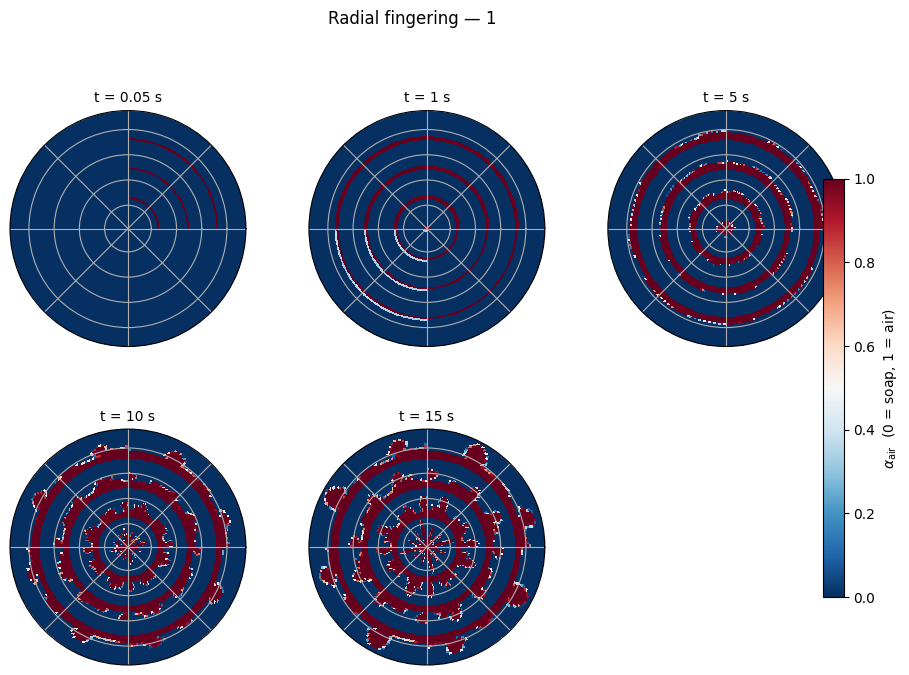

Cartesian (cartesian.png):


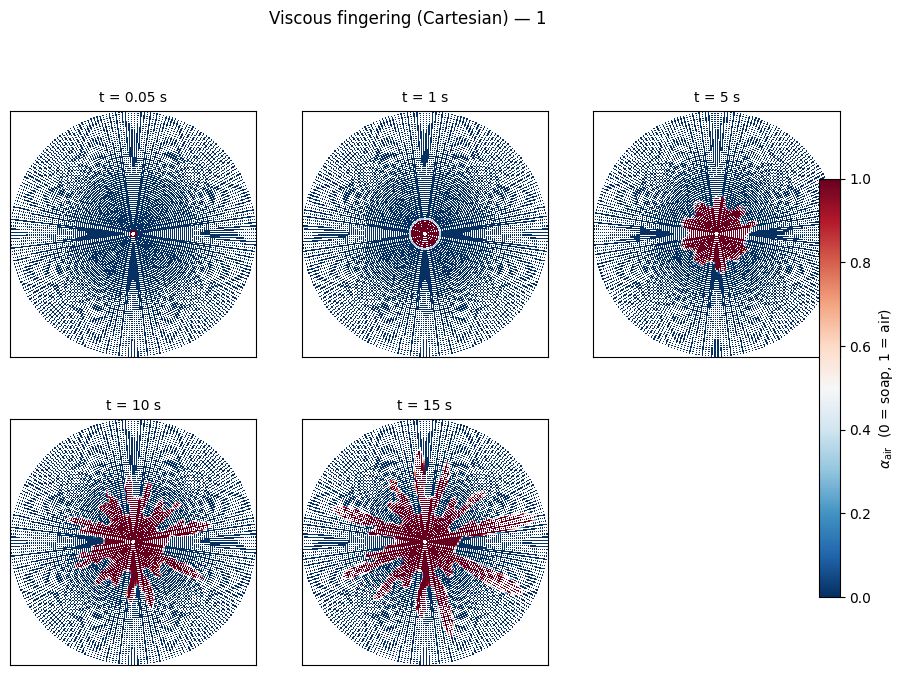

plot_fingers: wrote results/2/fingers.png (5/5 times, layout 2x3)
plot_cartesian: wrote results/2/cartesian.png (5/5 times, layout 2x3)

--- Configuration 2 ---
Polar (fingers.png):


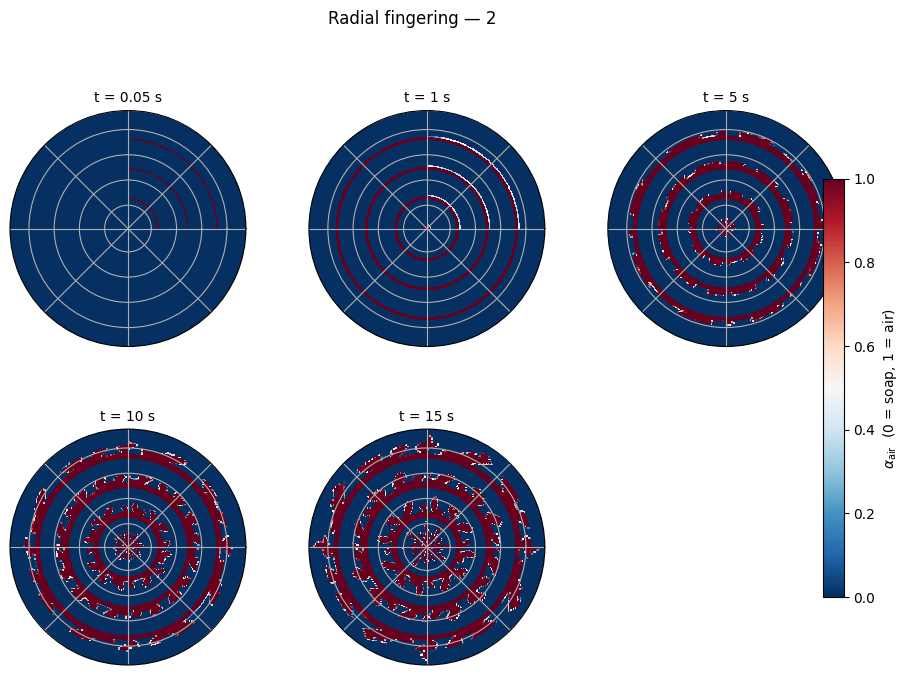

Cartesian (cartesian.png):


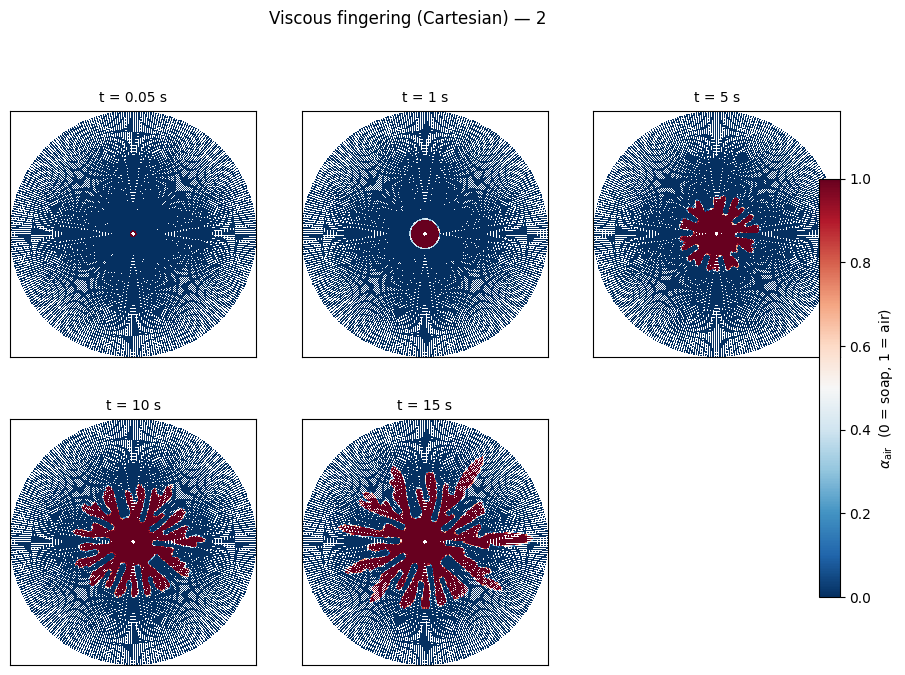

plot_fingers: wrote results/3/fingers.png (5/5 times, layout 2x3)
plot_cartesian: wrote results/3/cartesian.png (5/5 times, layout 2x3)

--- Configuration 3 ---
Polar (fingers.png):


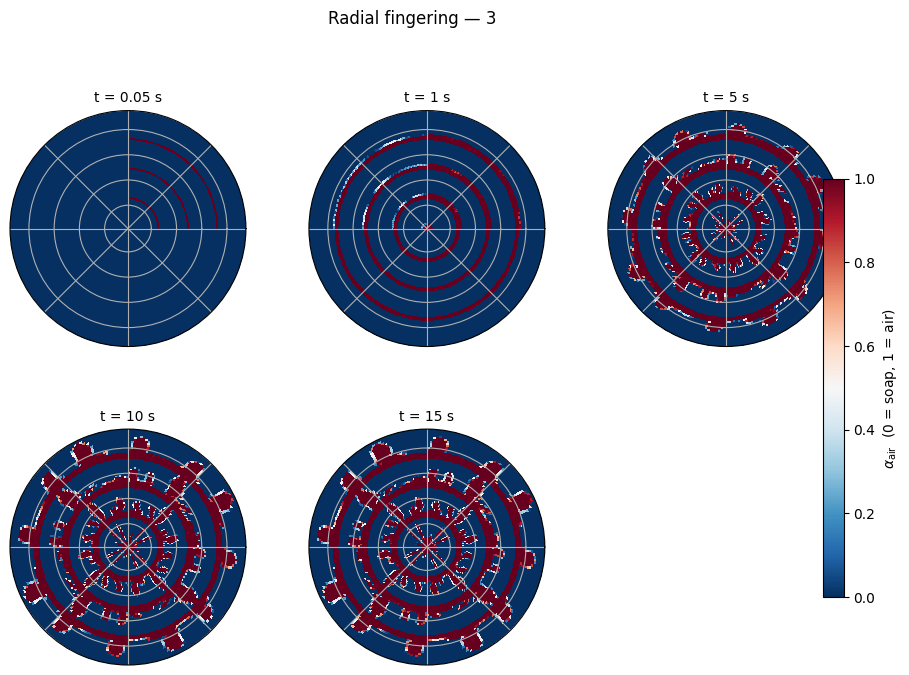

Cartesian (cartesian.png):


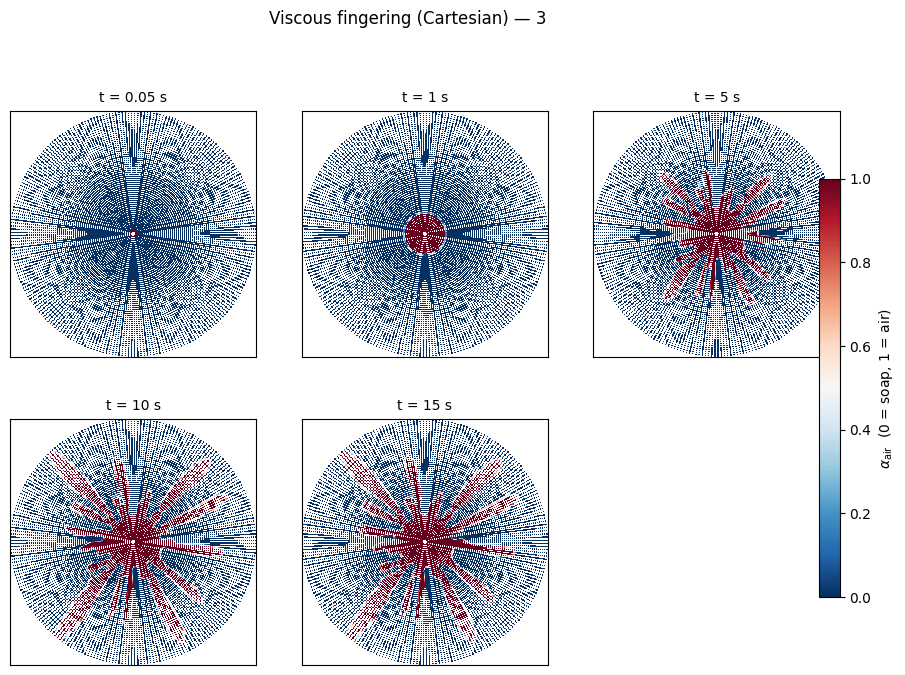

In [15]:
# Generate the polar + Cartesian fingers plots for each configuration
# and embed them in this notebook.
if RUN_SIM:
    from IPython.display import Image, display
    for cfg in CONFIGS:
        out_polar = Path("results") / cfg / "fingers.png"
        out_cart  = Path("results") / cfg / "cartesian.png"
        try:
            # Polar (r, theta) plot
            subprocess.run([
                "python", "openfoam/plot_fingers.py",
                "--results-dir", f"results/{cfg}",
                "--times", "0.05", "1", "5", "10", "15",
                "--output", str(out_polar),
            ], check=True)
            # Cartesian (X-Y) plot (the alien-like fingers)
            subprocess.run([
                "python", "openfoam/plot_fingers.py",
                "--results-dir", f"results/{cfg}",
                "--times", "0.05", "1", "5", "10", "15",
                "--output", str(out_cart),
                "--cartesian",
            ], check=True)
            print(f"\n--- Configuration {cfg} ---")
            # embed=True stores the image as base64 in the .ipynb
            # itself, so the figure renders in nbviewer / GitHub /
            # static export (not just in live Jupyter).
            print("Polar (fingers.png):")
            display(Image(filename=str(out_polar), embed=True, width=900))
            print("Cartesian (cartesian.png):")
            display(Image(filename=str(out_cart), embed=True, width=900))
        except subprocess.CalledProcessError as e:
            print(f"plot_fingers.py failed for {cfg}: {e}")
else:
    print("RUN_SIMULATION=0; skipping the fingers plot.")


In [16]:
# Inspect the alpha field at t=15 directly: cell count, air-cell count,
# interface-cell count. Sanity-check that the parser is working.
import sys
sys.path.insert(0, "openfoam")
from metrics import parse_alpha_field  # type: ignore[import-not-found]

if RUN_SIM:
    for cfg in CONFIGS:
        alpha_path = Path("results") / cfg / "15" / "alpha.air"
        if not alpha_path.exists():
            print(f"Skipping {cfg}: {alpha_path} not found")
            continue
        s = parse_alpha_field(str(alpha_path))
        if s is None:
            print(f"Configuration {cfg}: alpha field is uniform; skipping")
            continue
        print(f"Configuration {cfg} at t=15:")
        print(f"  total cells:     {s['n_cells']}")
        print(f"  air cells:       {s['n_air_cells']}")
        print(f"  interface cells: {s['n_interface_cells']}")
        print(f"  cell-fraction air: {s['phase1_volume_fraction']:.4f}")
        print()
else:
    print("RUN_SIMULATION=0; skipping the alpha field inspection.")


Configuration 1 at t=15:
  total cells:     14400
  air cells:       5881
  interface cells: 2141
  cell-fraction air: 0.4084

Configuration 2 at t=15:
  total cells:     25600
  air cells:       10343
  interface cells: 3821
  cell-fraction air: 0.4040

Configuration 3 at t=15:
  total cells:     14400
  air cells:       5770
  interface cells: 2599
  cell-fraction air: 0.4007



**Note on `phase1_volume_fraction`**: the value reported in
`solution_metrics.json` is the *solver-reported* phase-1 volume
fraction (an integral of $\alpha$ over the cell volumes), not the
cell-fraction-with-$\alpha > 0.5$ we just computed. The two are
different because `isoAdvector`'s compression step smears the
interface over ~3 cells. The solver-reported value is the ground
truth; the cell fraction is a sanity check.


### Compare to the runnable repo's reference

The reference Docker-runnable build
([`hele-shaw-cells-runnable`](https://github.com/Simulation-Benchmarks/hele-shaw-cells-example))
stores a bit-exact baseline in `tests/baseline/`. If you ran the
notebook on the same hardware with the same Docker image, your
`phase1_volume_fraction` at endTime should match to within `~0.01`
and the alpha field at t=15 should be bit-exact (`L_\infty = 0`).

If you ran on different hardware (especially under QEMU emulation),
the bit-exact match will not hold, but the bulk statistics (air
volume fraction, number of fingers) will be qualitatively similar.


In [ ]:
# Peek at the m4i-augmented RO-Crate inside one of the solution_field_data.zip
# files. This is the provenance the platform's SPARQL queries walk.
import tarfile

if RUN_SIM:
    sample_zip = Path("results") / CONFIGS[0] / "solution_field_data.zip"
    if not sample_zip.exists():
        print(f"{sample_zip} not found; skipping the RO-Crate peek")
    else:
        with tarfile.open(sample_zip, "r:gz") as tf:
            for member in tf.getmembers():
                if member.name == "ro-crate-metadata.json":
                    crate = json.loads(tf.extractfile(member).read())
                    break
        # Find the m4i:Method node.
        m4i_method = None
        for node in crate["@graph"]:
            t = node.get("@type", "")
            if "metadata4ing" in t and "Method" in t:
                m4i_method = node
                break
        if m4i_method is None:
            print("No m4i:Method node found in the RO-Crate.")
        else:
            print("m4i:Method node:")
            print(json.dumps(m4i_method, indent=2)[:1200])
            print("...")
else:
    print("RUN_SIMULATION=0; skipping the RO-Crate peek.")


## Where to go from here

- **Cross-benchmark SPARQL queries** — see `notebooks/RoCrate.ipynb`
  for the ROHub upload + SPARQL flow. The m4i:-augmented RO-Crate you
  just peeked at is the input to that notebook.
- **Troubleshooting** — see `docs/troubleshooting.md` if the simulation
  crashes or the smoke test fails.
- **Add a configuration** — copy `parameters_1.json` to
  `parameters_4.json`, edit it, and re-run the notebook. The workflow
  will pick it up automatically.
- **Add a tool** — drop a new folder under `openfoam/` (or a new top-
  level folder for a non-OF solver), implement the blueprint's
  `--input-parameter-file --input-mesh-file --output-solution-file-zip
  --output-metrics-file` arg contract, and update `generate_config.py`'s
  `--tools` list. See the platform's `benchmark_addition_guide.md`.
